In [1]:
# importing required packages and libraries for this excersize
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [3]:
# 1. Load the MNIST data set
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Preprocess the data
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

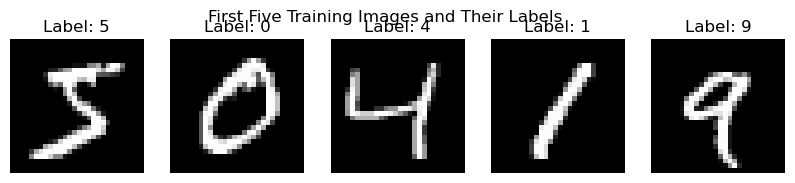

In [7]:
# 2. Display the first five images in the training data set
# 3. Compare these to the first five training labels
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("First Five Training Images and Their Labels")
plt.show()

In [9]:
# 4. Build and train a CNN classifier on the MNIST training set
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.1)


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9089 - loss: 0.3017 - val_accuracy: 0.9887 - val_loss: 0.0414
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9860 - loss: 0.0461 - val_accuracy: 0.9890 - val_loss: 0.0346
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9903 - loss: 0.0296 - val_accuracy: 0.9905 - val_loss: 0.0354
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9935 - loss: 0.0208 - val_accuracy: 0.9905 - val_loss: 0.0364
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9954 - loss: 0.0143 - val_accuracy: 0.9893 - val_loss: 0.0442


In [11]:
# 5. Report the test accuracy of your model
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {accuracy:.4f}")



Test Accuracy: 0.9871


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


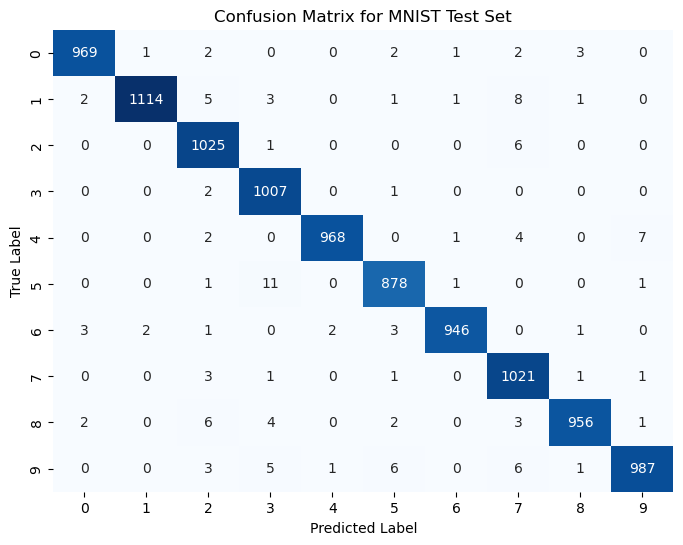

In [13]:
# 6. Display a confusion matrix on the test set classifications
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for MNIST Test Set')
plt.show()

In [15]:
# 7. Summarize your results
print("\nSummary of Results:")
print(f"The CNN model achieved a test accuracy of approximately {accuracy*100:.2f}% on the MNIST dataset.")
print("The confusion matrix visually represents the model's performance, showing the counts of correct and incorrect classifications for each digit.")
print("High values along the diagonal indicate correct predictions, while off-diagonal values represent misclassifications.")


Summary of Results:
The CNN model achieved a test accuracy of approximately 98.71% on the MNIST dataset.
The confusion matrix visually represents the model's performance, showing the counts of correct and incorrect classifications for each digit.
High values along the diagonal indicate correct predictions, while off-diagonal values represent misclassifications.
